# Практическая работа №1. Анализ FiresRu

**Цель:** изучить структуру данных, выполнить предобработку, статистический анализ, визуализацию и экспорт.

**Источник:** файл `FiresRu.csv` из задания. Каждая строка содержит тип события, координаты и метеорологические показатели. Даты наблюдений и единицы влажности и солнечной радиации не указаны.

## 2.1. Проверка окружения

In [1]:
from pathlib import Path
import csv
import io
import json
import platform
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib
import pyarrow
from IPython.display import display, Markdown

matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

ROOT = Path.cwd()
assert (ROOT / "FiresRu.csv").exists(), "Откройте ноутбук из папки практики BD."
OUT = ROOT / "output" / "fires"
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 3)
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11, "figure.dpi": 110})
versions = {"Python": platform.python_version(), "pandas": pd.__version__,
            "numpy": np.__version__, "matplotlib": matplotlib.__version__,
            "pyarrow": pyarrow.__version__}
display(pd.Series(versions, name="Версия").to_frame())
display(Markdown("**Вывод.** Библиотеки для анализа данных загружены."))

,Версия
Python,3.12.14
pandas,3.0.5
numpy,2.5.3
matplotlib,3.11.2
pyarrow,25.0.1


**Вывод.** Библиотеки для анализа данных загружены.

## 3.1-3.2. NumPy, Series и DataFrame

In [2]:
wind_ms = np.array([1.14, 0.80, 0.97])
print("Ветер, км/ч:", np.round(wind_ms * 3.6, 2))
s = pd.Series([10, 20, 30], name="value")
frame = pd.DataFrame({"type": ["A", "B", "A"], "value": [10, 20, 30]})
print(type(s).__name__, type(frame).__name__)
display(frame.groupby("type")["value"].sum().to_frame())
display(Markdown("**Вывод.** Векторное умножение переводит весь массив из м/с в км/ч. "
                 "Series представляет один столбец, DataFrame - таблицу. Суммы групп A и B равны 40 и 20."))

Ветер, км/ч: [4.1  2.88 3.49]
Series DataFrame


,value
type,
A,40
B,20


**Вывод.** Векторное умножение переводит весь массив из м/с в км/ч. Series представляет один столбец, DataFrame - таблицу. Суммы групп A и B равны 40 и 20.

## 4.1. Загрузка и паспорт данных

In [3]:
DATA_PATH = ROOT / "FiresRu.csv"
raw_text = DATA_PATH.read_text(encoding="utf-8-sig")
delimiter = csv.Sniffer().sniff(raw_text[:8192], delimiters=",;\t").delimiter
assert delimiter == ","
df = pd.read_csv(DATA_PATH, sep=delimiter, encoding="utf-8-sig")
print("Разделитель:", repr(delimiter), "; UTF-8 декодируется без ошибок")
print("Размер:", df.shape)
print("Столбцы:", df.columns.tolist())
assert df.shape == (26681, 9)
display(df.head())
meanings = {
    "type_name": "Название категории события", "type_id": "Код категории, не количественная величина",
    "lon": "Долгота, градусы", "lat": "Широта, градусы",
    "temperature_c": "Температура, °C", "precipitation_mm": "Осадки, мм",
    "relative_humidity": "Относительная влажность, единица не задана",
    "wind_speed_ms": "Скорость ветра, м/с", "solar_radiation": "Солнечная радиация, единица не задана",
}
display(pd.DataFrame({"Смысл": meanings, "dtype": df.dtypes.astype(str)}))
display(Markdown(f"**Вывод.** Прочитано {len(df):,} строк и {df.shape[1]} полей. "
                 "Разделитель и состав полей соответствуют методичке. Временного признака нет."))

Разделитель: ',' ; UTF-8 декодируется без ошибок
Размер: (26681, 9)
Столбцы: ['type_name', 'type_id', 'lon', 'lat', 'temperature_c', 'precipitation_mm', 'relative_humidity', 'wind_speed_ms', 'solar_radiation']


,type_name,type_id,lon,lat,temperature_c,precipitation_mm,relative_humidity,wind_speed_ms,solar_radiation
0,Natural fire,4,131.587,47.866,-9.44,0.01,72.98,1.14,4.59
1,Natural fire,4,131.589,47.881,-9.44,0.01,72.98,1.14,4.59
2,Forest fire,3,131.987,48.497,-10.71,0.05,81.31,0.80,4.24
3,Natural fire,4,131.903,43.628,-7.77,0.00,68.41,0.97,4.66
4,Natural fire,4,131.571,47.858,-9.44,0.01,72.98,1.14,4.59


,Смысл,dtype
type_name,Название категории события,str
type_id,"Код категории, не количественная величина",int64
lon,"Долгота, градусы",float64
lat,"Широта, градусы",float64
temperature_c,"Температура, °C",float64
precipitation_mm,"Осадки, мм",float64
relative_humidity,"Относительная влажность, единица не задана",float64
wind_speed_ms,"Скорость ветра, м/с",float64
solar_radiation,"Солнечная радиация, единица не задана",float64


**Вывод.** Прочитано 26,681 строк и 9 полей. Разделитель и состав полей соответствуют методичке. Временного признака нет.

## 5.1-5.2. Структура, память и качество

In [4]:
buf = io.StringIO()
df.info(buf=buf, memory_usage="deep")
print(buf.getvalue())
quality = pd.DataFrame({"Пропуски": df.isna().sum(), "Уникальных": df.nunique(),
                        "dtype": df.dtypes.astype(str)})
display(quality)
duplicates = int(df.duplicated().sum())
print("Полных дубликатов:", duplicates)
validity = pd.Series({
    "Долгота вне [-180; 180]": int((~df.lon.between(-180, 180)).sum()),
    "Широта вне [-90; 90]": int((~df.lat.between(-90, 90)).sum()),
    "Отрицательные осадки": int((df.precipitation_mm < 0).sum()),
    "Отрицательная скорость ветра": int((df.wind_speed_ms < 0).sum()),
    "Бесконечные числовые значения": int(np.isinf(df.select_dtypes("number")).sum().sum()),
}, name="Строк/значений")
display(validity.to_frame())
assert df.isna().sum().sum() == 0 and duplicates == 0 and validity.sum() == 0
display(Markdown("**Вывод.** Пропусков, полных дублей и нарушений проверенных диапазонов нет. "
                 "Удаление строк и заполнение пропусков не требуются."))

<class 'pandas.DataFrame'>
RangeIndex: 26681 entries, 0 to 26680
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   type_name          26681 non-null  str    
 1   type_id            26681 non-null  int64  
 2   lon                26681 non-null  float64
 3   lat                26681 non-null  float64
 4   temperature_c      26681 non-null  float64
 5   precipitation_mm   26681 non-null  float64
 6   relative_humidity  26681 non-null  float64
 7   wind_speed_ms      26681 non-null  float64
 8   solar_radiation    26681 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 2.1 MB



,Пропуски,Уникальных,dtype
type_name,0,5,str
type_id,0,5,int64
lon,0,25708,float64
lat,0,23547,float64
temperature_c,0,2581,float64
precipitation_mm,0,571,float64
relative_humidity,0,4028,float64
wind_speed_ms,0,532,float64
solar_radiation,0,731,float64


Полных дубликатов: 0


,Строк/значений
Долгота вне [-180; 180],0
Широта вне [-90; 90],0
Отрицательные осадки,0
Отрицательная скорость ветра,0
Бесконечные числовые значения,0


**Вывод.** Пропусков, полных дублей и нарушений проверенных диапазонов нет. Удаление строк и заполнение пропусков не требуются.

## 5.3. Соответствие кода и названия категории

In [5]:
type_map = df[["type_id", "type_name"]].drop_duplicates().sort_values("type_id")
display(type_map.reset_index(drop=True))
assert type_map.type_id.is_unique and type_map.type_name.is_unique
display(Markdown("**Вывод.** Пять кодов взаимно однозначно соответствуют пяти названиям. "
                 "Среднее `type_id` не имеет содержательной интерпретации, поэтому код исключён из EDA числовых величин."))

,type_id,type_name
0,1,Uncontrolled burn
1,2,Peat fire
2,3,Forest fire
3,4,Natural fire
4,5,Controlled burn


**Вывод.** Пять кодов взаимно однозначно соответствуют пяти названиям. Среднее `type_id` не имеет содержательной интерпретации, поэтому код исключён из EDA числовых величин.

## 5.4. Описательная статистика

In [6]:
cols = ["lon", "lat", "temperature_c", "precipitation_mm", "relative_humidity",
        "wind_speed_ms", "solar_radiation"]
description = df[cols].describe().T
display(description.round(2))
display(Markdown(
    f"**Вывод.** Температура: от {df.temperature_c.min():.2f} до {df.temperature_c.max():.2f} °C, "
    f"медиана {df.temperature_c.median():.2f} °C. Медиана осадков {df.precipitation_mm.median():.2f} мм "
    f"при максимуме {df.precipitation_mm.max():.2f} мм; медиана ветра {df.wind_speed_ms.median():.2f} м/с "
    f"при максимуме {df.wind_speed_ms.max():.2f} м/с. Большие верхние значения указывают на правые хвосты распределений."
))

,count,mean,std,min,25%,50%,75%,max
lon,26681.0,106.35,27.31,20.37,82.41,96.56,133.90,175.87
lat,26681.0,57.53,4.30,41.71,53.95,58.97,60.64,70.33
temperature_c,26681.0,17.89,5.68,-34.88,15.70,19.08,21.39,31.94
precipitation_mm,26681.0,0.46,1.46,0.00,0.00,0.04,0.30,25.85
relative_humidity,26681.0,69.44,11.43,24.70,62.93,71.35,77.91,99.83
wind_speed_ms,26681.0,0.63,0.93,0.00,0.11,0.25,0.66,7.42
solar_radiation,26681.0,5.57,1.50,0.42,4.55,5.68,6.71,8.97


**Вывод.** Температура: от -34.88 до 31.94 °C, медиана 19.08 °C. Медиана осадков 0.04 мм при максимуме 25.85 мм; медиана ветра 0.25 м/с при максимуме 7.42 м/с. Большие верхние значения указывают на правые хвосты распределений.

## 6.1. Оптимизация типов
Память сравнивается до добавления вычисляемых признаков, на одинаковых девяти столбцах.

In [7]:
before = int(df.memory_usage(deep=True).sum())
clean_df = df.copy()
clean_df["type_name"] = clean_df["type_name"].astype("category")
assert clean_df.type_id.between(np.iinfo(np.int8).min, np.iinfo(np.int8).max).all()
clean_df["type_id"] = clean_df["type_id"].astype("int8")
after = int(clean_df.memory_usage(deep=True).sum())
memory_reduction = (1 - after / before) * 100
display(pd.DataFrame({"Этап": ["До", "После"], "Байт": [before, after],
                      "MiB": [before / 1024**2, after / 1024**2]}))
pd.testing.assert_frame_equal(df, clean_df.astype(df.dtypes))
display(Markdown(f"**Вывод.** Память уменьшилась на **{memory_reduction:.1f}%**. "
                 "`category` заменяет повторяющиеся строки кодами, `int8` достаточен для кодов 1-5. "
                 "Значения после обратного приведения типов совпадают с исходными."))

,Этап,Байт,MiB
0,До,2237394,2.134
1,После,1547735,1.476


**Вывод.** Память уменьшилась на **30.8%**. `category` заменяет повторяющиеся строки кодами, `int8` достаточен для кодов 1-5. Значения после обратного приведения типов совпадают с исходными.

## 6.2. Вычисляемые признаки
`wind_speed_kmh = round(wind_speed_ms * 3.6, 2)`; `is_forest_fire = (type_name == 'Forest fire')`.

In [8]:
clean_df["wind_speed_kmh"] = (clean_df.wind_speed_ms * 3.6).round(2)
clean_df["is_forest_fire"] = clean_df.type_name.eq("Forest fire")
display(clean_df[["type_name", "wind_speed_ms", "wind_speed_kmh", "is_forest_fire"]].head())
display(Markdown("**Вывод.** Добавлены скорость ветра в км/ч и логический признак лесного пожара."))

,type_name,wind_speed_ms,wind_speed_kmh,is_forest_fire
0,Natural fire,1.14,4.10,False
1,Natural fire,1.14,4.10,False
2,Forest fire,0.80,2.88,True
3,Natural fire,0.97,3.49,False
4,Natural fire,1.14,4.10,False


**Вывод.** Добавлены скорость ветра в км/ч и логический признак лесного пожара.

## 7.1-7.2. Частоты и групповые средние

In [9]:
type_stats = df.type_name.value_counts().to_frame("n").assign(share_pct=lambda x: x.n / len(df) * 100)
display(type_stats.round(2))
group_stats = clean_df.groupby("type_name", observed=True).agg(
    n=("type_name", "size"), temp_mean=("temperature_c", "mean"),
    precip_mean=("precipitation_mm", "mean"), humidity_mean=("relative_humidity", "mean"),
    wind_mean=("wind_speed_ms", "mean"), solar_mean=("solar_radiation", "mean"),
).sort_values("n", ascending=False)
display(group_stats.round(2))
display(Markdown(
    f"**Вывод.** Forest fire: {type_stats.loc['Forest fire', 'n']:,} наблюдений "
    f"({type_stats.loc['Forest fire', 'share_pct']:.2f}%). Peat fire: "
    f"{type_stats.loc['Peat fire', 'n']:,} ({type_stats.loc['Peat fire', 'share_pct']:.2f}%). "
    "Размеры групп различаются, что следует учитывать при сравнении средних."
))

,n,share_pct
type_name,,
Forest fire,18415,69.02
Natural fire,5195,19.47
Uncontrolled burn,2711,10.16
Controlled burn,333,1.25
Peat fire,27,0.10


,n,temp_mean,precip_mean,humidity_mean,wind_mean,solar_mean
type_name,,,,,,
Forest fire,18415,18.69,0.50,70.30,0.42,5.87
Natural fire,5195,17.42,0.40,69.07,0.80,5.14
Uncontrolled burn,2711,14.21,0.29,64.35,1.64,4.57
Controlled burn,333,10.78,0.25,69.46,1.46,4.27
Peat fire,27,18.17,0.55,65.47,1.19,5.26


**Вывод.** Forest fire: 18,415 наблюдений (69.02%). Peat fire: 27 (0.10%). Размеры групп различаются, что следует учитывать при сравнении средних.

## 7.3. Составной фильтр

In [10]:
subset = df.loc[(df.relative_humidity < 40) & (df.wind_speed_ms > 2),
                ["type_name", "lon", "lat", "temperature_c", "relative_humidity", "wind_speed_ms"]]
query_subset = df.query("relative_humidity < 40 and wind_speed_ms > 2")
assert subset.index.equals(query_subset.index)
display(subset.head())
display(Markdown(f"**Вывод.** Найдено {len(subset)} строк ({len(subset)/len(df):.2%}). "
                 "Результаты фильтрации через `loc` и `query` совпадают."))

,type_name,lon,lat,temperature_c,relative_humidity,wind_speed_ms
295,Forest fire,91.393,51.057,15.15,27.97,2.55
478,Forest fire,104.584,50.372,14.67,37.89,2.64
479,Forest fire,104.494,50.359,14.67,37.89,2.64
480,Forest fire,104.419,50.330,14.67,37.89,2.64
481,Forest fire,104.300,50.338,14.67,37.89,2.64


**Вывод.** Найдено 337 строк (1.26%). Результаты фильтрации через `loc` и `query` совпадают.

## 8.1-8.2. Корреляция и кандидаты на выбросы

In [11]:
weather = ["temperature_c", "precipitation_mm", "relative_humidity", "wind_speed_ms", "solar_radiation"]
corr = df[weather].corr()
display(corr.round(3))
q1, q3 = df.wind_speed_ms.quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
mask = (df.wind_speed_ms < lower) | (df.wind_speed_ms > upper)
print(f"Q1={q1:.3f}; Q3={q3:.3f}; IQR={iqr:.3f}; границы=[{lower:.3f}; {upper:.3f}]")
print(f"Кандидатов: {mask.sum()} ({mask.mean():.2%})")
display(Markdown(
    f"**Вывод.** Для температуры и ветра r = {corr.loc['temperature_c', 'wind_speed_ms']:.3f}; "
    "сильной линейной зависимости между погодными признаками нет. Нулевой коэффициент не исключает нелинейную связь. "
    f"IQR выделяет {mask.sum():,} строк: это кандидаты для проверки, все они сохранены. "
))

,temperature_c,precipitation_mm,relative_humidity,wind_speed_ms,solar_radiation
temperature_c,1.000,0.003,-0.155,-0.297,0.221
precipitation_mm,0.003,1.000,0.232,-0.047,-0.192
relative_humidity,-0.155,0.232,1.000,-0.280,-0.234
wind_speed_ms,-0.297,-0.047,-0.280,1.000,-0.189
solar_radiation,0.221,-0.192,-0.234,-0.189,1.000


Q1=0.110; Q3=0.660; IQR=0.550; границы=[-0.715; 1.485]
Кандидатов: 3652 (13.69%)


**Вывод.** Для температуры и ветра r = -0.297; сильной линейной зависимости между погодными признаками нет. Нулевой коэффициент не исключает нелинейную связь. IQR выделяет 3,652 строк: это кандидаты для проверки, все они сохранены. 

## 9.1. Сравнение категорий

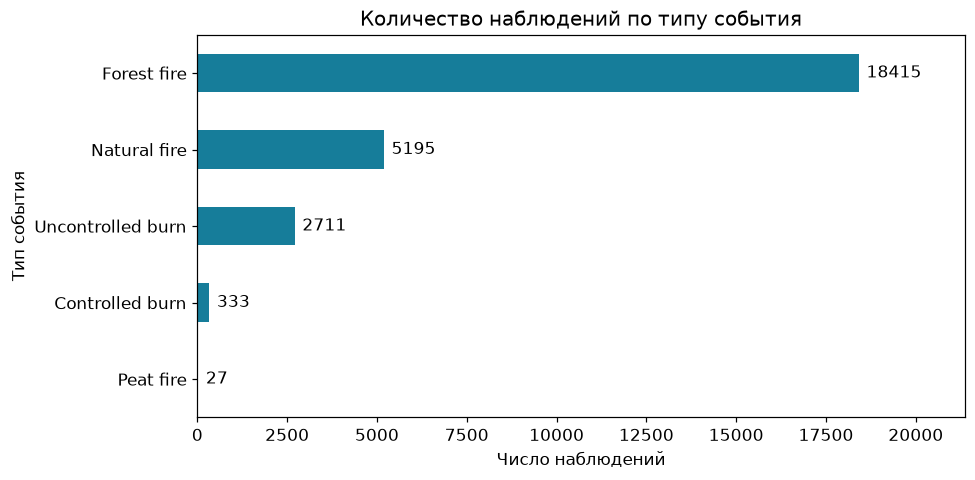

**Вывод.** На диаграмме преобладает категория Forest fire; распределение категорий неравномерно.

In [12]:
counts = df.type_name.value_counts().sort_values()
ax = counts.plot.barh(figsize=(9, 4.5), color="#167d9a")
ax.bar_label(ax.containers[0], padding=5, fmt="%.0f")
ax.set(xlabel="Число наблюдений", ylabel="Тип события", title="Количество наблюдений по типу события")
ax.set_xlim(0, counts.max() * 1.16)
plt.tight_layout()
plt.savefig(FIG / "01_types.png", dpi=150)
plt.show()
display(Markdown("**Вывод.** На диаграмме преобладает категория Forest fire; распределение категорий неравномерно."))

## 9.2. Распределение температуры

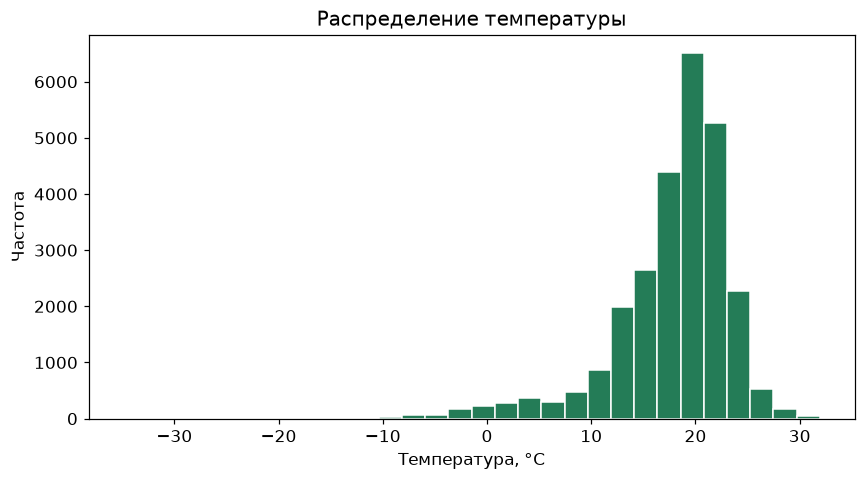

**Вывод.** Основная масса температур положительна; распределение имеет длинный левый хвост. Отрицательные температуры нельзя объявить ошибками без проверки источника.

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df.temperature_c, bins=30, edgecolor="white", color="#247c57")
ax.set(xlabel="Температура, °C", ylabel="Частота", title="Распределение температуры")
plt.tight_layout()
plt.savefig(FIG / "02_temperature.png", dpi=150)
plt.show()
display(Markdown("**Вывод.** Основная масса температур положительна; распределение имеет длинный левый хвост. "
                 "Отрицательные температуры нельзя объявить ошибками без проверки источника."))

## 9.3. Температура и влажность

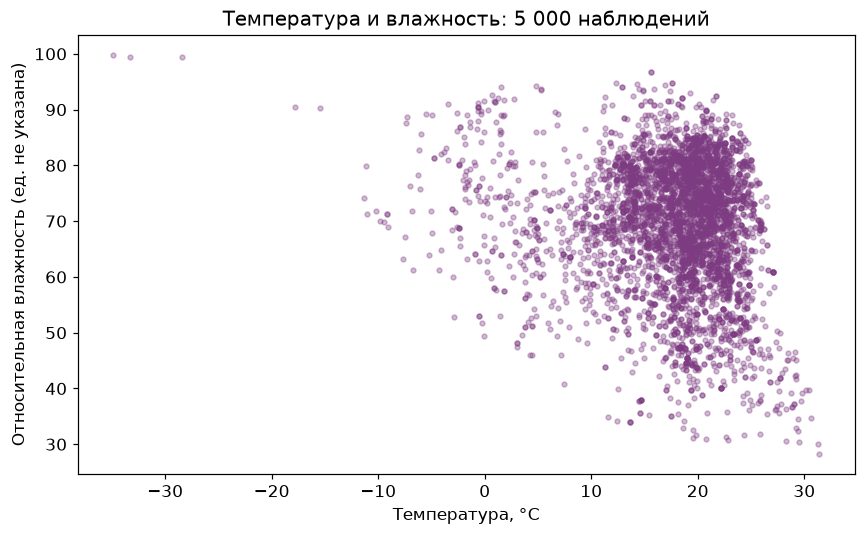

**Вывод.** Облако точек широкое, линейная связь слабо отрицательная (r по всему набору = -0.155). 

In [14]:
sample = df.sample(n=5000, random_state=42)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample.temperature_c, sample.relative_humidity, s=10, alpha=0.35, color="#7d3b81")
ax.set(xlabel="Температура, °C", ylabel="Относительная влажность (ед. не указана)",
       title="Температура и влажность: 5 000 наблюдений")
plt.tight_layout()
plt.savefig(FIG / "03_temperature_humidity.png", dpi=150)
plt.show()
display(Markdown(f"**Вывод.** Облако точек широкое, линейная связь слабо отрицательная "
                 f"(r по всему набору = {corr.loc['temperature_c', 'relative_humidity']:.3f}). "))

## 9.4. Пространственное распределение

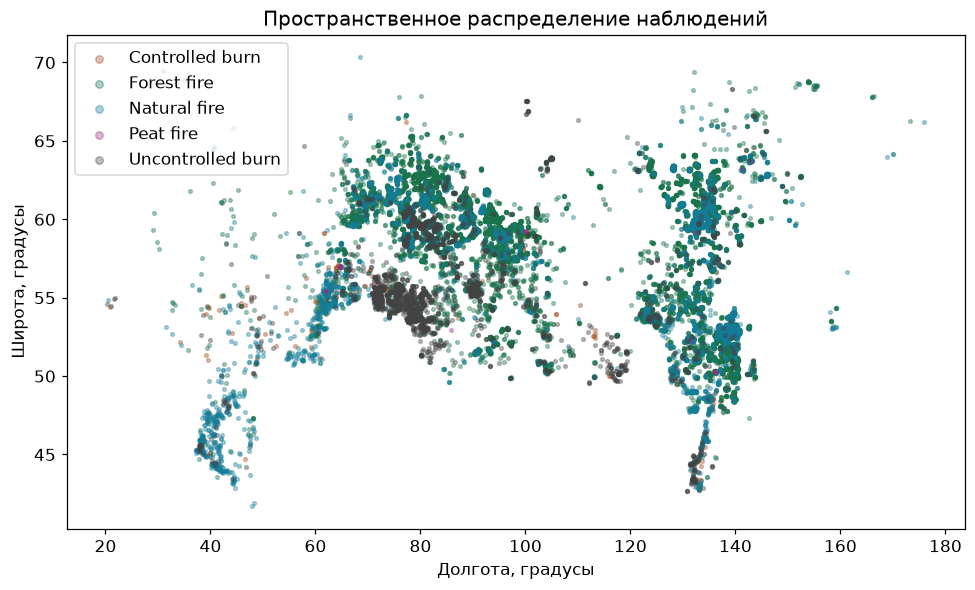

**Вывод.** Наблюдения пространственно неоднородны, видны скопления точек. График показывает расположение событий по долготе и широте.

In [15]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for (name, part), color in zip(df.groupby("type_name", observed=True),
                             ["#a34b19", "#19734b", "#147d99", "#9a3080", "#434343"]):
    ax.scatter(part.lon, part.lat, s=6, alpha=0.35, label=name, color=color)
ax.set(xlabel="Долгота, градусы", ylabel="Широта, градусы", title="Пространственное распределение наблюдений")
ax.legend(loc="upper left", markerscale=2)
plt.tight_layout()
plt.savefig(FIG / "04_coordinates.png", dpi=150)
plt.show()
display(Markdown("**Вывод.** Наблюдения пространственно неоднородны, видны скопления точек. "
                 "График показывает расположение событий по долготе и широте."))

## 10.1-10.2. Экспорт и проверка повторного чтения
Во всех форматах сохраняется одна таблица из 11 столбцов. Время чтения - медиана
пяти последовательных запусков в текущем окружении с прогретым файловым кешем;
это локальный замер, а не универсальное сравнение производительности.

In [16]:
clean_df.to_csv(OUT / "FiresRu_clean.csv", index=False, encoding="utf-8")
clean_df.to_json(OUT / "FiresRu_clean.json", orient="records", lines=True, force_ascii=False, double_precision=15)
clean_df.to_parquet(OUT / "FiresRu_clean.parquet", index=False, engine="pyarrow", compression="snappy")
readers = {
    "csv": lambda: pd.read_csv(OUT / "FiresRu_clean.csv", encoding="utf-8"),
    "json": lambda: pd.read_json(OUT / "FiresRu_clean.json", orient="records", lines=True),
    "parquet": lambda: pd.read_parquet(OUT / "FiresRu_clean.parquet", engine="pyarrow"),
}
back = {fmt: reader() for fmt, reader in readers.items()}
file_stats = []
for fmt, reader in readers.items():
    restored = back[fmt]
    assert restored.shape == clean_df.shape
    if fmt == "parquet":
        pd.testing.assert_frame_equal(clean_df, restored, check_exact=True)
    else:
        pd.testing.assert_frame_equal(clean_df, restored.astype(clean_df.dtypes),
                                      check_exact=False, rtol=1e-10, atol=1e-9)
    durations = []
    for _ in range(5):
        start = perf_counter()
        reader()
        durations.append((perf_counter() - start) * 1000)
    path = OUT / f"FiresRu_clean.{fmt}"
    file_stats.append({"Формат": fmt, "Байт": path.stat().st_size,
                       "MiB": path.stat().st_size / 1024**2, "Чтение, мс": np.median(durations),
                       "Строк": len(restored), "Столбцов": len(restored.columns), "Значения совпали": True})
file_stats = pd.DataFrame(file_stats).set_index("Формат")
display(file_stats)
display(pd.DataFrame({"До записи": clean_df.dtypes.astype(str),
                      **{fmt: data.dtypes.astype(str) for fmt, data in back.items()}}))
selected_columns = ["type_name", "temperature_c"]
partial = pd.read_parquet(OUT / "FiresRu_clean.parquet", columns=selected_columns)
pd.testing.assert_frame_equal(partial, clean_df[selected_columns])
display(Markdown("**Вывод.** Во всех трёх файлах совпадают строки, столбцы и значения "
                 "(для текстовых чисел допуск 1e-9 плюс относительный 1e-10). Parquet сохранил "
                 "значения и dtypes точно, включая `category` и `int8`. CSV/JSON потребовали "
                 "обратного приведения по известной схеме. Выборочное чтение двух колонок Parquet проверено; "
                 "у CSV `usecols` тоже ограничивает результат, но текст всё равно приходится разбирать."))

,Байт,MiB,"Чтение, мс",Строк,Столбцов,Значения совпали
Формат,,,,,,
csv,1827275,1.743,12.098,26681,11,True
json,7183440,6.851,100.844,26681,11,True
parquet,635707,0.606,2.613,26681,11,True


,До записи,csv,json,parquet
type_name,category,str,str,category
type_id,int8,int64,int64,int8
lon,float64,float64,float64,float64
lat,float64,float64,float64,float64
temperature_c,float64,float64,float64,float64
precipitation_mm,float64,float64,float64,float64
relative_humidity,float64,float64,float64,float64
wind_speed_ms,float64,float64,float64,float64
solar_radiation,float64,float64,float64,float64
wind_speed_kmh,float64,float64,float64,float64


**Вывод.** Во всех трёх файлах совпадают строки, столбцы и значения (для текстовых чисел допуск 1e-9 плюс относительный 1e-10). Parquet сохранил значения и dtypes точно, включая `category` и `int8`. CSV/JSON потребовали обратного приведения по известной схеме. Выборочное чтение двух колонок Parquet проверено; у CSV `usecols` тоже ограничивает результат, но текст всё равно приходится разбирать.

## 11. Итоговые выводы и ограничения

In [17]:
summary = {
    "source_rows": len(df), "source_columns": df.shape[1], "clean_rows": len(clean_df),
    "clean_columns": clean_df.shape[1], "missing": int(df.isna().sum().sum()),
    "duplicates": duplicates, "memory_before_bytes": before, "memory_after_bytes": after,
    "memory_reduction_pct": memory_reduction, "filter_rows": len(subset),
    "wind_iqr_candidates": int(mask.sum()), "forest_share_pct": float(type_stats.loc["Forest fire", "share_pct"]),
    "roundtrip_all_formats": True,
}
(OUT / "summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
type_stats.to_csv(OUT / "type_stats.csv", encoding="utf-8")
group_stats.to_csv(OUT / "group_stats.csv", encoding="utf-8")
file_stats.to_csv(OUT / "format_comparison.csv", encoding="utf-8")
display(Markdown(f"""
1. В исходном файле {len(df):,} строк и 9 признаков. Пропуски и полные дубли отсутствуют, все строки сохранены.
2. Пять категорий сильно несбалансированы: доля Forest fire составляет {type_stats.loc['Forest fire', 'share_pct']:.2f}%, Peat fire представлен 27 строками.
3. Код `type_id` не является измеряемой величиной и исключён из числовой статистики и корреляции.
4. Оптимизация одинаковых исходных столбцов снизила память на {memory_reduction:.1f}% без потери значений.
5. Медиана температуры равна {df.temperature_c.median():.2f} °C; у осадков и скорости ветра выражены правые хвосты.
6. Учебному фильтру влажности и ветра соответствуют {len(subset)} строк.
7. IQR помечает {mask.sum():,} скоростей ветра ({mask.mean():.2%}); основания для автоматического удаления отсутствуют.
8. Экспортировано {clean_df.shape[1]} столбцов в CSV, JSON Lines и Parquet, обратное чтение проверено по содержимому.

**Ограничения.** Нет дат, поэтому нельзя исследовать сезонность и динамику. Нет описания схемы сбора,
поэтому нельзя переносить доли на все пожары России. Единицы влажности и радиации не подтверждены.
Пространственная близость может нарушать независимость наблюдений; корреляции не доказывают причинность.
"""))


1. В исходном файле 26,681 строк и 9 признаков. Пропуски и полные дубли отсутствуют, все строки сохранены.
2. Пять категорий сильно несбалансированы: доля Forest fire составляет 69.02%, Peat fire представлен 27 строками.
3. Код `type_id` не является измеряемой величиной и исключён из числовой статистики и корреляции.
4. Оптимизация одинаковых исходных столбцов снизила память на 30.8% без потери значений.
5. Медиана температуры равна 19.08 °C; у осадков и скорости ветра выражены правые хвосты.
6. Учебному фильтру влажности и ветра соответствуют 337 строк.
7. IQR помечает 3,652 скоростей ветра (13.69%); основания для автоматического удаления отсутствуют.
8. Экспортировано 11 столбцов в CSV, JSON Lines и Parquet, обратное чтение проверено по содержимому.

**Ограничения.** Нет дат, поэтому нельзя исследовать сезонность и динамику. Нет описания схемы сбора,
поэтому нельзя переносить доли на все пожары России. Единицы влажности и радиации не подтверждены.
Пространственная близость может нарушать независимость наблюдений; корреляции не доказывают причинность.


# Практическая работа №1. Самостоятельный анализ Bike Sharing

**Цель:** исследовать связь дневного числа прокатов с погодой и типом дня, а также изменение спроса во времени.

**Данные:** `day.csv`, дневные наблюдения Capital Bikeshare за 2011–2012 годы, Вашингтон, США.

**Источник:** Fanaee-T, H. (2013). [Bike Sharing — UCI Machine Learning Repository](https://doi.org/10.24432/C5W894). Лицензия: [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).

## 1. Окружение и загрузка

In [18]:
from pathlib import Path
import csv
import hashlib
import io
import json
import platform
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib
import pyarrow
from IPython.display import display, Markdown

matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "bike_sharing" / "day.csv"
assert DATA_PATH.exists(), "Сначала выполните scripts/download_data.py из папки практики."
OUT = ROOT / "output" / "bike_sharing"
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 25)
pd.set_option("display.precision", 3)
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11, "figure.dpi": 110})
display(pd.Series({"Python": platform.python_version(), "pandas": pd.__version__,
                   "numpy": np.__version__, "matplotlib": matplotlib.__version__,
                   "pyarrow": pyarrow.__version__}, name="Версия").to_frame())
source = json.loads((DATA_PATH.parent / "source.json").read_text(encoding="utf-8"))
assert hashlib.sha256(DATA_PATH.read_bytes()).hexdigest() == source["day_csv_sha256"]
text = DATA_PATH.read_text(encoding="utf-8-sig")
delimiter = csv.Sniffer().sniff(text[:8192], delimiters=",;\t").delimiter
assert delimiter == ","
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig", sep=delimiter)
print("Разделитель:", repr(delimiter), "; UTF-8 читается без ошибок; размер:", df.shape)
display(df.head())
assert df.shape == (731, 16)
display(Markdown("**Вывод.** Загружена таблица: 731 строка, "
                 "16 исходных полей, несколько числовых показателей и категориальные коды. "
                 "Столбец `dteday` содержит дату наблюдения."))

,Версия
Python,3.12.14
pandas,3.0.5
numpy,2.5.3
matplotlib,3.11.2
pyarrow,25.0.1


Разделитель: ',' ; UTF-8 читается без ошибок; размер: (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344,0.364,0.806,0.160,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363,0.354,0.696,0.249,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196,0.189,0.437,0.248,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200,0.212,0.590,0.160,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.227,0.229,0.437,0.187,82,1518,1600


**Вывод.** Загружена таблица: 731 строка, 16 исходных полей, несколько числовых показателей и категориальные коды. Столбец `dteday` содержит дату наблюдения.

## 2. Паспорт данных и диагностика

В описаниях UCI и архивного Readme различаются названия сезонов и нормировка температуры. Поэтому `season` используется как код, а `temp` и `atemp` — в нормированной шкале. Влажность переводится в проценты: `hum * 100`.

In [19]:
dictionary = {
    "instant": "Индекс записи; не измеряемый признак",
    "dteday": "Дата дня наблюдения, YYYY-MM-DD",
    "season": "Категория сезона 1-4; названия расходятся в метаданных",
    "yr": "Код года: 0 = 2011, 1 = 2012",
    "mnth": "Месяц: 1-12",
    "holiday": "Праздничный день: 1 = да, 0 = нет",
    "weekday": "День недели: 0 = воскресенье, ..., 6 = суббота; проверяется по дате",
    "workingday": "Рабочий день: не выходной и не праздник",
    "weathersit": "Погода: 1 = ясно/мало облаков, 2 = туман/облачность, 3 = небольшие осадки, 4 = сильные осадки",
    "temp": "Нормированная температура, без обратного перевода в °C",
    "atemp": "Нормированная ощущаемая температура",
    "hum": "Нормированная относительная влажность: исходное значение / 100",
    "windspeed": "Нормированная скорость ветра",
    "casual": "Число прокатов незарегистрированными пользователями за день",
    "registered": "Число прокатов зарегистрированными пользователями за день",
    "cnt": "Общее число прокатов за день: casual + registered",
}
display(pd.DataFrame({"Смысл": dictionary, "Исходный dtype": df.dtypes.astype(str)}))
buf = io.StringIO()
df.info(buf=buf, memory_usage="deep")
print(buf.getvalue())
display(df.describe(include="all").T)
display(Markdown("**Вывод.** Pandas распознал дату строкой, а категориальные коды - целыми числами. "
                 "Категориальные коды исключаются из числового анализа."))

,Смысл,Исходный dtype
instant,Индекс записи; не измеряемый признак,int64
dteday,"Дата дня наблюдения, YYYY-MM-DD",str
season,Категория сезона 1-4; названия расходятся в ме...,int64
yr,"Код года: 0 = 2011, 1 = 2012",int64
mnth,Месяц: 1-12,int64
holiday,"Праздничный день: 1 = да, 0 = нет",int64
weekday,"День недели: 0 = воскресенье, ..., 6 = суббота...",int64
workingday,Рабочий день: не выходной и не праздник,int64
weathersit,"Погода: 1 = ясно/мало облаков, 2 = туман/облач...",int64
temp,"Нормированная температура, без обратного перев...",float64


<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 98.6 KB



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
instant,731.0,NaN,NaN,NaN,366.0,211.166,1.0,183.5,366.0,548.5,731.0
dteday,731,731,2011-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,731.0,NaN,NaN,NaN,2.497,1.111,1.0,2.0,3.0,3.0,4.0
yr,731.0,NaN,NaN,NaN,0.501,0.5,0.0,0.0,1.0,1.0,1.0
mnth,731.0,NaN,NaN,NaN,6.52,3.452,1.0,4.0,7.0,10.0,12.0
holiday,731.0,NaN,NaN,NaN,0.029,0.167,0.0,0.0,0.0,0.0,1.0
weekday,731.0,NaN,NaN,NaN,2.997,2.005,0.0,1.0,3.0,5.0,6.0
workingday,731.0,NaN,NaN,NaN,0.684,0.465,0.0,0.0,1.0,1.0,1.0
weathersit,731.0,NaN,NaN,NaN,1.395,0.545,1.0,1.0,1.0,2.0,3.0
temp,731.0,NaN,NaN,NaN,0.495,0.183,0.059,0.337,0.498,0.655,0.862


**Вывод.** Pandas распознал дату строкой, а категориальные коды - целыми числами. Категориальные коды исключаются из числового анализа.

## 3. Качество и предобработка

In [20]:
quality = pd.DataFrame({"Пропуски": df.isna().sum(), "Уникальных": df.nunique()})
display(quality)
duplicates = int(df.duplicated().sum())
print("Полных дубликатов:", duplicates)
dates = pd.to_datetime(df.dteday, format="%Y-%m-%d", errors="raise")
checks = pd.Series({
    "Повторные даты": int(dates.duplicated().sum()),
    "Повторные идентификаторы": int(df.instant.duplicated().sum()),
    "Нарушения cnt = casual + registered": int(df.cnt.ne(df.casual + df.registered).sum()),
    "Отрицательные счётчики": int((df[["casual", "registered", "cnt"]] < 0).any(axis=1).sum()),
    "Нормированные значения вне [0; 1]": int((~df[["temp", "atemp", "hum", "windspeed"]].apply(lambda s: s.between(0, 1))).any(axis=1).sum()),
    "Бесконечные числа": int(np.isinf(df.select_dtypes("number")).sum().sum()),
    "Год не совпадает с датой": int((df.yr + 2011).ne(dates.dt.year).sum()),
    "Месяц не совпадает с датой": int(df.mnth.ne(dates.dt.month).sum()),
    "День недели не совпадает с датой": int(df.weekday.ne((dates.dt.dayofweek + 1) % 7).sum()),
    "Признак рабочего дня противоречив": int(df.workingday.ne((~df.weekday.isin([0, 6]) & df.holiday.eq(0)).astype(int)).sum()),
}, name="Нарушений")
display(checks.to_frame())
missing_days = pd.date_range(dates.min(), dates.max()).difference(pd.DatetimeIndex(dates))
print("Пропущенных календарных дней:", len(missing_days))
assert quality["Пропуски"].sum() == 0 and duplicates == 0 and checks.sum() == 0 and len(missing_days) == 0
for col, allowed in {"season": [1, 2, 3, 4], "weathersit": [1, 2, 3, 4],
                     "yr": [0, 1], "holiday": [0, 1], "workingday": [0, 1]}.items():
    assert df[col].isin(allowed).all()
zero_humidity = df.loc[df.hum.eq(0), ["dteday", "hum", "cnt"]]
display(zero_humidity)
display(Markdown(f"**Вывод.** Пропусков и полных дублей нет; даты уникальны и календарный ряд непрерывен. "
                 f"Обнаружено {len(zero_humidity)} дней с нулевой суточной влажностью. "
                 "Нулевая влажность отмечена отдельным признаком; строки сохранены."))

,Пропуски,Уникальных
instant,0,731
dteday,0,731
season,0,4
yr,0,2
mnth,0,12
holiday,0,2
weekday,0,7
workingday,0,2
weathersit,0,3
temp,0,499


Полных дубликатов: 0


,Нарушений
Повторные даты,0
Повторные идентификаторы,0
Нарушения cnt = casual + registered,0
Отрицательные счётчики,0
Нормированные значения вне [0; 1],0
Бесконечные числа,0
Год не совпадает с датой,0
Месяц не совпадает с датой,0
День недели не совпадает с датой,0
Признак рабочего дня противоречив,0


Пропущенных календарных дней: 0


,dteday,hum,cnt
68,2011-03-10,0.0,623


**Вывод.** Пропусков и полных дублей нет; даты уникальны и календарный ряд непрерывен. Обнаружено 1 дней с нулевой суточной влажностью. Нулевая влажность отмечена отдельным признаком; строки сохранены.

## 4. Типы и память
Сравниваются одинаковые 16 исходных столбцов, до добавления новых признаков.
Счётчики переводятся в минимальный подходящий беззнаковый целый тип.

In [21]:
before = int(df.memory_usage(deep=True).sum())
clean_df = df.copy()
clean_df["dteday"] = dates
categorical = ["season", "yr", "mnth", "weekday", "weathersit"]
for col in categorical:
    clean_df[col] = clean_df[col].astype("category")
for col in ["holiday", "workingday"]:
    clean_df[col] = clean_df[col].astype(bool)
for col in ["instant", "casual", "registered", "cnt"]:
    clean_df[col] = pd.to_numeric(clean_df[col], downcast="unsigned")
after = int(clean_df.memory_usage(deep=True).sum())
memory_reduction = (1 - after / before) * 100
display(pd.DataFrame({"До": df.dtypes.astype(str), "После": clean_df.dtypes.astype(str)}))
display(pd.DataFrame({"Этап": ["До", "После"], "Байт": [before, after],
                      "KiB": [before / 1024, after / 1024]}))
reversed_df = clean_df.copy()
reversed_df["dteday"] = reversed_df.dteday.dt.strftime("%Y-%m-%d")
pd.testing.assert_frame_equal(df, reversed_df.astype(df.dtypes))
display(Markdown(f"**Вывод.** Память снижена на {memory_reduction:.1f}%. Дата стала `datetime`, "
                 "коды - категориями, бинарные поля - логическими. Проверено обратное восстановление "
                 "всех исходных значений. Вещественные измерения оставлены `float64`, чтобы не снижать точность."))

,До,После
instant,int64,uint16
dteday,str,datetime64[us]
season,int64,category
yr,int64,category
mnth,int64,category
holiday,int64,bool
weekday,int64,category
workingday,int64,bool
weathersit,int64,category
temp,float64,float64


,Этап,Байт,KiB
0,До,101010,98.643
1,После,40561,39.610


**Вывод.** Память снижена на 59.8%. Дата стала `datetime`, коды - категориями, бинарные поля - логическими. Проверено обратное восстановление всех исходных значений. Вещественные измерения оставлены `float64`, чтобы не снижать точность.

## 5. Вычисляемые признаки
`humidity_pct = hum * 100`; `casual_share_pct = casual / cnt * 100`;
`humidity_zero_flag = (hum == 0)`. Доля определяется только для дней с `cnt > 0`.

In [22]:
assert clean_df.cnt.gt(0).all()
clean_df["humidity_pct"] = clean_df.hum * 100
clean_df["casual_share_pct"] = clean_df.casual / clean_df.cnt * 100
clean_df["humidity_zero_flag"] = clean_df.hum.eq(0)
display(clean_df[["dteday", "hum", "humidity_pct", "casual", "cnt", "casual_share_pct", "humidity_zero_flag"]].head())
display(Markdown("**Вывод.** Влажность представлена в процентах согласно нормировке источника. "
                 "Доля незарегистрированных пользователей характеризует состав дневного спроса; "
                 "индикатор нулевой влажности сохраняет информацию о потенциально сомнительном измерении."))

,dteday,hum,humidity_pct,casual,cnt,casual_share_pct,humidity_zero_flag
0,2011-01-01,0.806,80.583,331,985,33.604,False
1,2011-01-02,0.696,69.609,131,801,16.355,False
2,2011-01-03,0.437,43.727,120,1349,8.895,False
3,2011-01-04,0.590,59.044,108,1562,6.914,False
4,2011-01-05,0.437,43.696,82,1600,5.125,False


**Вывод.** Влажность представлена в процентах согласно нормировке источника. Доля незарегистрированных пользователей характеризует состав дневного спроса; индикатор нулевой влажности сохраняет информацию о потенциально сомнительном измерении.

## 6. Составной фильтр
Выбираются рабочие дни с нормированной температурой выше 0.5 и влажностью ниже 65%.

In [23]:
subset = clean_df.loc[clean_df.workingday & (clean_df.temp > 0.5) & (clean_df.humidity_pct < 65),
                      ["dteday", "temp", "humidity_pct", "cnt"]]
query_subset = clean_df.query("workingday == True and temp > 0.5 and humidity_pct < 65")
assert subset.index.equals(query_subset.index)
display(subset.head())
display(Markdown(f"**Вывод.** Условия выполняются в {len(subset)} днях ({len(subset)/len(df):.2%} наблюдений). "
                 f"Среднее число прокатов в срезе {subset.cnt.mean():.1f}, во всём наборе {clean_df.cnt.mean():.1f}. "))

,dteday,temp,humidity_pct,cnt
48,2011-02-18,0.522,51.667,2927
76,2011-03-18,0.540,52.522,3239
93,2011-04-04,0.573,42.625,3115
107,2011-04-18,0.512,54.250,3429
109,2011-04-20,0.595,61.417,3944


**Вывод.** Условия выполняются в 125 днях (17.10% наблюдений). Среднее число прокатов в срезе 5946.5, во всём наборе 4504.3. 

## 7. Группировки и несколько агрегатных функций
Сравниваем погоду и рабочие/нерабочие дни. Для каждой категории приводим объём группы.
Общая доля casual рассчитывается как отношение сумм, а не среднее дневных процентов.

In [24]:
weather_stats = clean_df.groupby("weathersit", observed=True).agg(
    days=("cnt", "size"), mean_rentals=("cnt", "mean"), median_rentals=("cnt", "median"),
    std_rentals=("cnt", "std"), total_rentals=("cnt", "sum"),
).sort_index()
day_stats = clean_df.groupby("workingday", observed=True).agg(
    days=("cnt", "size"), mean_rentals=("cnt", "mean"), mean_casual=("casual", "mean"),
    mean_registered=("registered", "mean"), casual_total=("casual", "sum"), total=("cnt", "sum"),
)
day_stats["casual_share_pct"] = day_stats.casual_total / day_stats.total * 100
display(weather_stats.round(2))
display(day_stats.round(2))
best_weather = weather_stats.mean_rentals.idxmax()
display(Markdown(
    f"**Вывод.** Наибольший средний спрос у погодной категории {best_weather}: "
    f"{weather_stats.loc[best_weather, 'mean_rentals']:.1f} прокатов/день. "
    f"Доля casual в суммарных прокатах рабочих дней {day_stats.loc[True, 'casual_share_pct']:.2f}%, "
    f"нерабочих - {day_stats.loc[False, 'casual_share_pct']:.2f}%. Состав спроса различается. "
    "Число дней неодинаково, поэтому средний дневной спрос информативнее одной только суммы по группе."
))

,days,mean_rentals,median_rentals,std_rentals,total_rentals
weathersit,,,,,
1,463,4876.79,4844.0,1879.48,2257952
2,247,4035.86,4040.0,1809.11,996858
3,21,1803.29,1817.0,1240.28,37869


,days,mean_rentals,mean_casual,mean_registered,casual_total,total,casual_share_pct
workingday,,,,,,,
False,231,4330.17,1371.13,2959.03,316732,1000269,31.66
True,500,4584.82,606.57,3978.25,303285,2292410,13.23


**Вывод.** Наибольший средний спрос у погодной категории 1: 4876.8 прокатов/день. Доля casual в суммарных прокатах рабочих дней 13.23%, нерабочих - 31.66%. Состав спроса различается. Число дней неодинаково, поэтому средний дневной спрос информативнее одной только суммы по группе.

## 8. Числовая статистика, корреляции и IQR
Категориальные коды и индекс исключены. `casual` и `registered` не включены
в корреляцию с `cnt`, поскольку сумма этих двух столбцов точно равна цели.

In [25]:
numeric = ["temp", "atemp", "humidity_pct", "windspeed", "cnt"]
display(clean_df[numeric].describe().T.round(3))
corr = clean_df[numeric].corr()
display(corr.round(3))
outlier_rows = []
for col in ["cnt", "temp", "humidity_pct", "windspeed"]:
    q1, q3 = clean_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    candidates = ~clean_df[col].between(lower, upper)
    outlier_rows.append({"Признак": col, "Q1": q1, "Q3": q3, "IQR": iqr,
                         "Нижняя граница": lower, "Верхняя граница": upper,
                         "Кандидатов": int(candidates.sum()), "Доля, %": candidates.mean() * 100})
outliers = pd.DataFrame(outlier_rows).set_index("Признак")
display(outliers.round(3))
humidity_corr_without_zero = clean_df.loc[~clean_df.humidity_zero_flag, ["humidity_pct", "cnt"]].corr().iloc[0, 1]
display(Markdown(
    f"**Вывод.** Корреляция температуры со спросом r = {corr.loc['temp', 'cnt']:.3f}. "
    f"Для влажности r = {corr.loc['humidity_pct', 'cnt']:.3f}; при исключении нулевой влажности "
    f"только из расчёта этой корреляции r = {humidity_corr_without_zero:.3f}. "
    f"IQR выделяет {int(outliers.loc['cnt', 'Кандидатов'])} дней по спросу и "
    f"{int(outliers.loc['windspeed', 'Кандидатов'])} по ветру. Наблюдения сохранены: "
    "экстремальная погода и спрос могут быть реальными, а глобальный IQR не учитывает сезонность. "
    "Корреляции описательные и не отделяют влияние календаря от погоды."
))

,count,mean,std,min,25%,50%,75%,max
temp,731.0,0.495,0.183,0.059,0.337,0.498,0.655,0.862
atemp,731.0,0.474,0.163,0.079,0.338,0.487,0.609,0.841
humidity_pct,731.0,62.789,14.243,0.000,52.000,62.667,73.021,97.250
windspeed,731.0,0.190,0.077,0.022,0.135,0.181,0.233,0.507
cnt,731.0,4504.349,1937.211,22.000,3152.000,4548.000,5956.000,8714.000


,temp,atemp,humidity_pct,windspeed,cnt
temp,1.000,0.992,0.127,-0.158,0.627
atemp,0.992,1.000,0.140,-0.184,0.631
humidity_pct,0.127,0.140,1.000,-0.248,-0.101
windspeed,-0.158,-0.184,-0.248,1.000,-0.235
cnt,0.627,0.631,-0.101,-0.235,1.000


,Q1,Q3,IQR,Нижняя граница,Верхняя граница,Кандидатов,"Доля, %"
Признак,,,,,,,
cnt,3152.000,5956.000,2804.000,-1054.000,10162.000,0,0.000
temp,0.337,0.655,0.318,-0.140,1.133,0,0.000
humidity_pct,52.000,73.021,21.021,20.469,104.552,2,0.274
windspeed,0.135,0.233,0.098,-0.012,0.381,13,1.778


**Вывод.** Корреляция температуры со спросом r = 0.627. Для влажности r = -0.101; при исключении нулевой влажности только из расчёта этой корреляции r = -0.115. IQR выделяет 0 дней по спросу и 13 по ветру. Наблюдения сохранены: экстремальная погода и спрос могут быть реальными, а глобальный IQR не учитывает сезонность. Корреляции описательные и не отделяют влияние календаря от погоды.

## 9.1. Категориальное сравнение

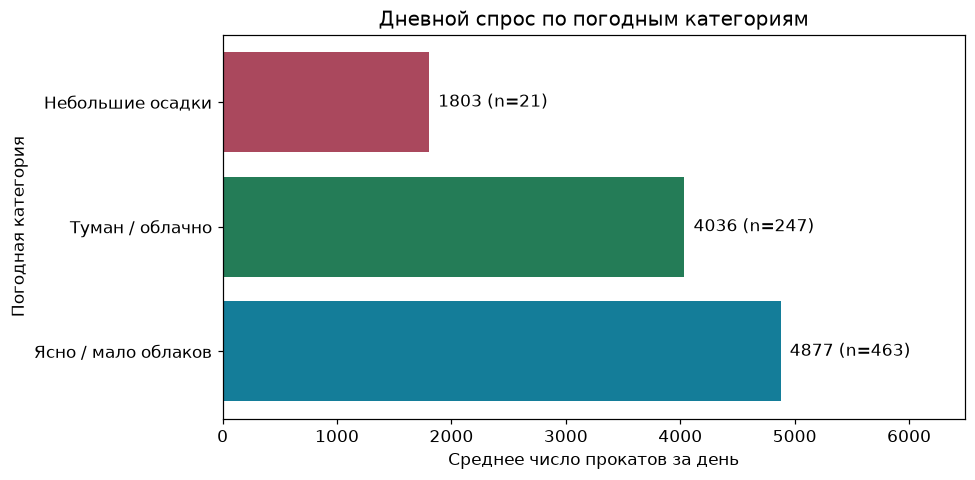

**Вывод.** В дни с небольшими осадками средний спрос ниже, чем в ясные дни. Число наблюдений указано в подписях. Категория 4 в данных отсутствует.

In [26]:
weather_labels = {1: "Ясно / мало облаков", 2: "Туман / облачно", 3: "Небольшие осадки", 4: "Сильные осадки"}
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh([weather_labels[int(i)] for i in weather_stats.index], weather_stats.mean_rentals,
               color=["#147d99", "#247c57", "#aa485d"][:len(weather_stats)])
ax.bar_label(bars, labels=[f"{mean:.0f} (n={int(n)})" for mean, n in
                         zip(weather_stats.mean_rentals, weather_stats.days)], padding=6)
ax.set_xlim(0, weather_stats.mean_rentals.max() * 1.33)
ax.set(xlabel="Среднее число прокатов за день", ylabel="Погодная категория",
       title="Дневной спрос по погодным категориям")
plt.tight_layout()
plt.savefig(FIG / "01_weather.png", dpi=150)
plt.show()
display(Markdown("**Вывод.** В дни с небольшими осадками средний спрос ниже, чем в ясные дни. "
                 "Число наблюдений указано в подписях. Категория 4 в данных отсутствует."))

## 9.2. Распределение спроса

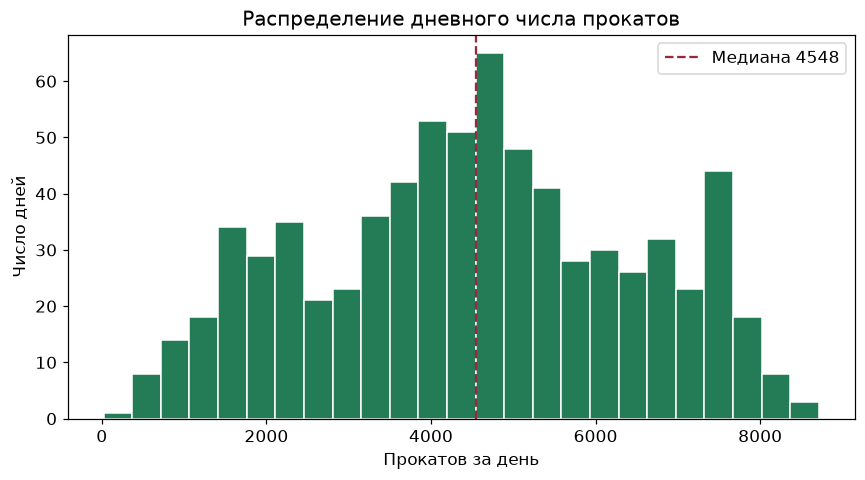

**Вывод.** Дневной спрос меняется от 22 до 8714 прокатов, медиана 4548. Распределение объединяет два года и разные сезоны.

In [27]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(clean_df.cnt, bins=25, color="#247c57", edgecolor="white")
ax.axvline(clean_df.cnt.median(), color="#99283f", linestyle="--", label=f"Медиана {clean_df.cnt.median():.0f}")
ax.set(xlabel="Прокатов за день", ylabel="Число дней", title="Распределение дневного числа прокатов")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "02_demand.png", dpi=150)
plt.show()
display(Markdown(f"**Вывод.** Дневной спрос меняется от {clean_df.cnt.min()} до {clean_df.cnt.max()} "
                 f"прокатов, медиана {clean_df.cnt.median():.0f}. Распределение объединяет два года "
                 "и разные сезоны."))

## 9.3. Взаимосвязь температуры и спроса

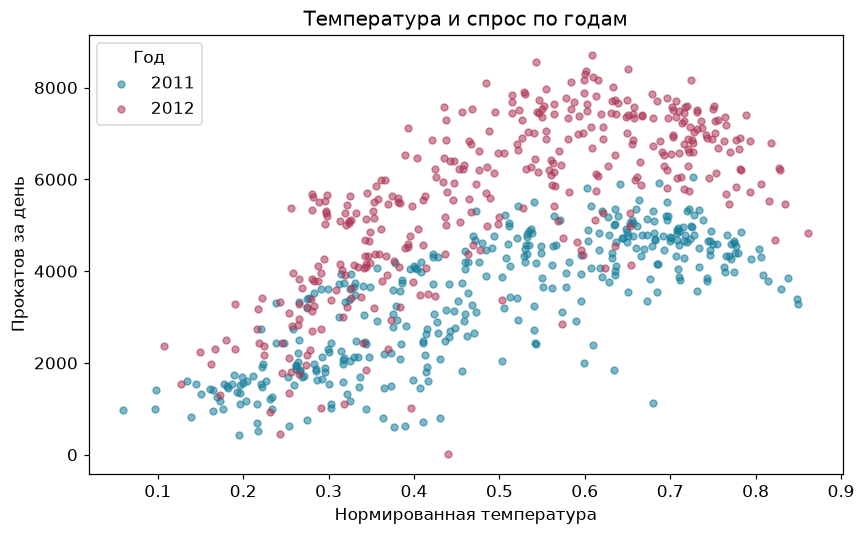

**Вывод.** Видна положительная связь температуры со спросом, но облака двух лет сдвинуты: при сопоставимой температуре спрос в 2012 году обычно выше.

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
for year, color in [(2011, "#147d99"), (2012, "#ad3554")]:
    part = clean_df.loc[clean_df.dteday.dt.year.eq(year)]
    ax.scatter(part.temp, part.cnt, s=20, alpha=0.55, label=str(year), color=color)
ax.set(xlabel="Нормированная температура", ylabel="Прокатов за день", title="Температура и спрос по годам")
ax.legend(title="Год")
plt.tight_layout()
plt.savefig(FIG / "03_temperature_demand.png", dpi=150)
plt.show()
display(Markdown("**Вывод.** Видна положительная связь температуры со спросом, но облака двух лет "
                 "сдвинуты: при сопоставимой температуре спрос в 2012 году обычно выше."))

## 9.4. Временная агрегация
`resample('MS')` объединяет дни по календарным месяцам. Для графика используется
среднее за день, чтобы длина месяца не влияла напрямую на сравнение.
Месячные суммы также рассчитываются и сохраняются.

,days,total_rentals,mean_daily_rentals
dteday,,,
2011-01-01,31,38189,1231.90
2011-02-01,28,48215,1721.96
2011-03-01,31,64045,2065.97
2011-04-01,30,94870,3162.33
2011-05-01,31,135821,4381.32
2011-06-01,30,143512,4783.73
2011-07-01,31,141341,4559.39
2011-08-01,31,136691,4409.39
2011-09-01,30,127418,4247.27


,days,total_rentals,mean_daily_rentals
dteday,,,
2011,365,1243103,3405.76
2012,366,2049576,5599.93


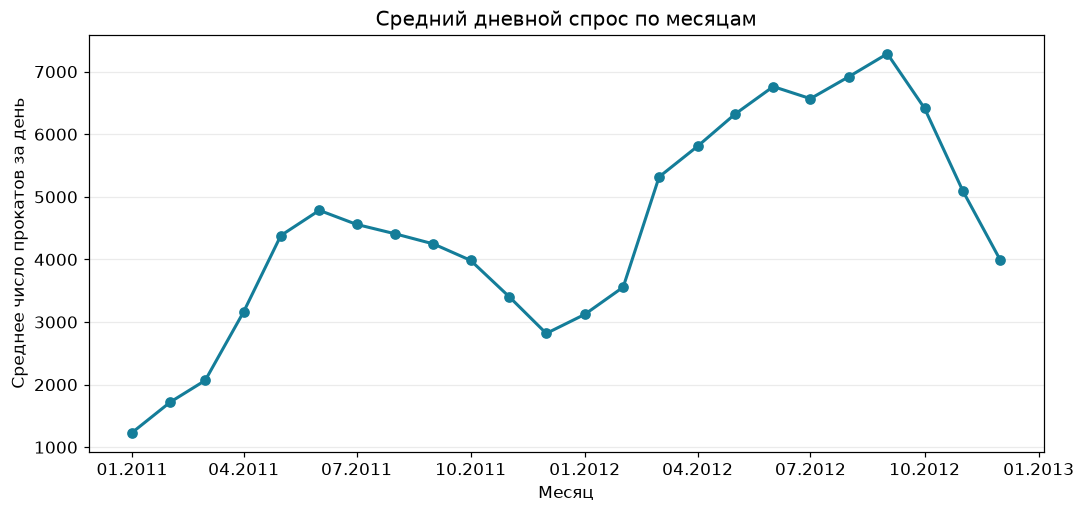

**Вывод.** Средний дневной спрос 2012 года выше 2011 года на 64.43%. Максимальное месячное среднее приходится на 09.2012: 7285.8 прокатов/день. Видны сезонные колебания; двух годовых циклов недостаточно для устойчивого долгосрочного прогноза.

In [29]:
monthly = clean_df.set_index("dteday").sort_index().resample("MS").agg(
    days=("cnt", "size"), total_rentals=("cnt", "sum"), mean_daily_rentals=("cnt", "mean"),
)
yearly = clean_df.groupby(clean_df.dteday.dt.year).agg(
    days=("cnt", "size"), total_rentals=("cnt", "sum"), mean_daily_rentals=("cnt", "mean"),
)
assert monthly.days.sum() == len(clean_df) and monthly.total_rentals.sum() == clean_df.cnt.sum()
display(monthly.round(2))
display(yearly.round(2))
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(monthly.index, monthly.mean_daily_rentals, marker="o", color="#147d99", linewidth=2)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m.%Y"))
ax.set(xlabel="Месяц", ylabel="Среднее число прокатов за день", title="Средний дневной спрос по месяцам")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIG / "04_monthly.png", dpi=150)
plt.show()
growth = (yearly.loc[2012, "mean_daily_rentals"] / yearly.loc[2011, "mean_daily_rentals"] - 1) * 100
peak = monthly.mean_daily_rentals.idxmax()
display(Markdown(f"**Вывод.** Средний дневной спрос 2012 года выше 2011 года на {growth:.2f}%. "
                 f"Максимальное месячное среднее приходится на {peak:%m.%Y}: "
                 f"{monthly.loc[peak, 'mean_daily_rentals']:.1f} прокатов/день. "
                 "Видны сезонные колебания; двух годовых циклов недостаточно для устойчивого долгосрочного прогноза."))

## 10. Экспорт, схема и проверка повторного чтения
Сохраняется одна таблица из 731 строки и 19 полей. CSV и JSON не сохраняют
полную схему Pandas. В этом окружении Parquet также восстанавливает числовые
категории как int64. Схема сохраняется в отдельном JSON и восстанавливается явно.
Времена чтения - медианы пяти повторов с прогретым кешем, зависящие от компьютера.

In [30]:
clean_df.to_csv(OUT / "BikeSharing_clean.csv", index=False, encoding="utf-8", date_format="%Y-%m-%d")
clean_df.to_json(OUT / "BikeSharing_clean.json", orient="records", lines=True, force_ascii=False,
                 date_format="iso", double_precision=15)
clean_df.to_parquet(OUT / "BikeSharing_clean.parquet", index=False, engine="pyarrow", compression="snappy")
schema = {}
for col, dtype in clean_df.dtypes.items():
    schema[col] = {"dtype": str(dtype)}
    if isinstance(dtype, pd.CategoricalDtype):
        schema[col].update(categories=dtype.categories.tolist(), ordered=dtype.ordered)
(OUT / "BikeSharing_schema.json").write_text(json.dumps(schema, indent=2), encoding="utf-8")
saved_schema = json.loads((OUT / "BikeSharing_schema.json").read_text(encoding="utf-8"))
restore_dtypes = {
    col: (pd.CategoricalDtype(meta["categories"], ordered=meta["ordered"])
          if meta["dtype"] == "category" else meta["dtype"])
    for col, meta in saved_schema.items()
}
readers = {
    "csv": lambda: pd.read_csv(OUT / "BikeSharing_clean.csv", encoding="utf-8", parse_dates=["dteday"]),
    "json": lambda: pd.read_json(OUT / "BikeSharing_clean.json", orient="records", lines=True, convert_dates=["dteday"]),
    "parquet": lambda: pd.read_parquet(OUT / "BikeSharing_clean.parquet", engine="pyarrow"),
}
back = {fmt: reader() for fmt, reader in readers.items()}
file_stats = []
for fmt, reader in readers.items():
    restored = back[fmt]
    assert restored.shape == clean_df.shape
    if fmt == "parquet":
        pd.testing.assert_frame_equal(clean_df, restored.astype(restore_dtypes), check_exact=True)
    else:
        pd.testing.assert_frame_equal(clean_df, restored.astype(restore_dtypes),
                                      check_exact=False, rtol=1e-10, atol=1e-9)
    durations = []
    for _ in range(5):
        start = perf_counter()
        reader()
        durations.append((perf_counter() - start) * 1000)
    path = OUT / f"BikeSharing_clean.{fmt}"
    file_stats.append({"Формат": fmt, "Байт": path.stat().st_size,
                       "KiB": path.stat().st_size / 1024, "Чтение, мс": np.median(durations),
                       "Строк": len(restored), "Столбцов": len(restored.columns), "Значения совпали": True,
                       "Типы совпали без приведения": restored.dtypes.equals(clean_df.dtypes)})
file_stats = pd.DataFrame(file_stats).set_index("Формат")
display(file_stats)
display(pd.DataFrame({"До записи": clean_df.dtypes.astype(str),
                      **{fmt: data.dtypes.astype(str) for fmt, data in back.items()}}))
partial = pd.read_parquet(OUT / "BikeSharing_clean.parquet", columns=["dteday", "cnt"])
pd.testing.assert_frame_equal(partial, clean_df[["dteday", "cnt"]])
display(Markdown("**Вывод.** Во всех форматах восстановлены все строки и значения (для текстовых "
                 "чисел допуск 1e-9 плюс относительный 1e-10). Parquet сохранил точные числовые значения, "
                 "дату, компактные счётчики и bool, но числовые категории вернулись как int64. "
                 "Полная схема успешно восстановлена из `BikeSharing_schema.json` и проверена. "
                 "Проверено выборочное чтение даты и числа прокатов из Parquet."))
print("Размер схемы, байт:", (OUT / "BikeSharing_schema.json").stat().st_size)

,Байт,KiB,"Чтение, мс",Строк,Столбцов,Значения совпали,Типы совпали без приведения
Формат,,,,,,,
csv,88382,86.311,2.052,731,19,True,False
json,251341,245.450,4.728,731,19,True,False
parquet,63888,62.391,1.484,731,19,True,False


,До записи,csv,json,parquet
instant,uint16,int64,int64,uint16
dteday,datetime64[us],datetime64[us],datetime64[us],datetime64[us]
season,category,int64,int64,int64
yr,category,int64,int64,int64
mnth,category,int64,int64,int64
holiday,bool,bool,bool,bool
weekday,category,int64,int64,int64
workingday,bool,bool,bool,bool
weathersit,category,int64,int64,int64
temp,float64,float64,float64,float64


**Вывод.** Во всех форматах восстановлены все строки и значения (для текстовых чисел допуск 1e-9 плюс относительный 1e-10). Parquet сохранил точные числовые значения, дату, компактные счётчики и bool, но числовые категории вернулись как int64. Полная схема успешно восстановлена из `BikeSharing_schema.json` и проверена. Проверено выборочное чтение даты и числа прокатов из Parquet.

Размер схемы, байт: 1426


## 11. Итоговые выводы и ограничения

In [31]:
summary = {
    "source_rows": len(df), "source_columns": df.shape[1], "clean_rows": len(clean_df),
    "clean_columns": clean_df.shape[1], "missing": int(df.isna().sum().sum()), "duplicates": duplicates,
    "first_date": dates.min().strftime("%Y-%m-%d"), "last_date": dates.max().strftime("%Y-%m-%d"),
    "memory_before_bytes": before, "memory_after_bytes": after, "memory_reduction_pct": memory_reduction,
    "filter_rows": len(subset), "zero_humidity_rows": len(zero_humidity),
    "temperature_demand_correlation": float(corr.loc["temp", "cnt"]),
    "mean_daily_growth_pct_2012": growth, "peak_month": peak.strftime("%Y-%m"),
    "roundtrip_all_formats": True,
    "parquet_requires_category_restore": not back["parquet"].dtypes.equals(clean_df.dtypes),
}
(OUT / "summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
weather_stats.to_csv(OUT / "weather_stats.csv", encoding="utf-8")
day_stats.to_csv(OUT / "workingday_stats.csv", encoding="utf-8")
monthly.to_csv(OUT / "monthly_stats.csv", encoding="utf-8")
yearly.to_csv(OUT / "yearly_stats.csv", encoding="utf-8")
outliers.to_csv(OUT / "iqr_stats.csv", encoding="utf-8")
file_stats.to_csv(OUT / "format_comparison.csv", encoding="utf-8")
display(Markdown(f"""
1. Набор содержит {len(df)} последовательных дней с {dates.min():%d.%m.%Y} по {dates.max():%d.%m.%Y}, без пропусков и полных дублей.
2. Оптимизация 16 исходных столбцов снизила память на {memory_reduction:.1f}%, сохранив значения.
3. Выявлено {len(zero_humidity)} дней с нулевой влажностью. Добавлен индикатор для дальнейшей проверки; строки не удалялись.
4. Средний дневной спрос по всему набору {clean_df.cnt.mean():.1f}, медиана {clean_df.cnt.median():.0f}; разброс от {clean_df.cnt.min()} до {clean_df.cnt.max()}.
5. Корреляция нормированной температуры со спросом равна {corr.loc['temp', 'cnt']:.3f}; это не оценка причинного влияния.
6. Доля casual в суммарном спросе нерабочих дней {day_stats.loc[False, 'casual_share_pct']:.2f}%, рабочих дней {day_stats.loc[True, 'casual_share_pct']:.2f}%.
7. Средний дневной спрос в 2012 году вырос на {growth:.2f}% относительно 2011 года; пик месячного среднего - {peak:%m.%Y}.
8. Три формата экспорта прошли проверку содержимого. Числовые категории Parquet потребовали явного восстановления из сохранённой схемы; точность значений подтверждена.

**Ограничения анализа.**

- Одна система и два исторических года не представляют современные показатели других городов. Суточные агрегаты скрывают часы пик.
- Наблюдательные связи погоды и спроса смешиваются с календарём, развитием системы и другими факторами. Причинность не установлена.
- Метаданные температуры и сезонов противоречивы, поэтому сохранены нормированные значения и коды без спорной расшифровки.
- Истинный смысл нулевой влажности не подтверждён. Автоматическая замена на среднее могла бы скрыть проблему источника.
"""))


1. Набор содержит 731 последовательных дней с 01.01.2011 по 31.12.2012, без пропусков и полных дублей.
2. Оптимизация 16 исходных столбцов снизила память на 59.8%, сохранив значения.
3. Выявлено 1 дней с нулевой влажностью. Добавлен индикатор для дальнейшей проверки; строки не удалялись.
4. Средний дневной спрос по всему набору 4504.3, медиана 4548; разброс от 22 до 8714.
5. Корреляция нормированной температуры со спросом равна 0.627; это не оценка причинного влияния.
6. Доля casual в суммарном спросе нерабочих дней 31.66%, рабочих дней 13.23%.
7. Средний дневной спрос в 2012 году вырос на 64.43% относительно 2011 года; пик месячного среднего - 09.2012.
8. Три формата экспорта прошли проверку содержимого. Числовые категории Parquet потребовали явного восстановления из сохранённой схемы; точность значений подтверждена.

**Ограничения анализа.**

- Одна система и два исторических года не представляют современные показатели других городов. Суточные агрегаты скрывают часы пик.
- Наблюдательные связи погоды и спроса смешиваются с календарём, развитием системы и другими факторами. Причинность не установлена.
- Метаданные температуры и сезонов противоречивы, поэтому сохранены нормированные значения и коды без спорной расшифровки.
- Истинный смысл нулевой влажности не подтверждён. Автоматическая замена на среднее могла бы скрыть проблему источника.


# Практическая работа №1. Подробные ответы на контрольные вопросы

1. **Почему числовой dtype не гарантирует, что признак имеет количественный смысл?**

   **Простыми словами.** `dtype` сообщает компьютеру, как значение хранится в памяти: как целое число, число с дробной частью, строка и так далее. Но компьютер не знает предметного смысла столбца. Целое число может быть настоящим количеством, например числом поездок, а может быть кодом категории, номером строки или идентификатором объекта.

   **Как это работает.** Для количественного признака осмысленны арифметические действия и сравнение расстояний. Например, температура 20 °C действительно на 10 градусов больше температуры 10 °C. Для кода категории это неверно: код `4` не означает, что категория в два раза больше категории `2`. Среднее, сумма и разность таких кодов обычно не имеют предметного смысла, хотя Pandas технически позволит их вычислить.

   **Пример и вывод.** В FiresRu поле `type_id` хранится как целое число, но обозначает тип события. Значение `3` означает `Forest fire`, а `1` — `Uncontrolled burn`. Нельзя сказать, что лесной пожар «в три раза больше» неконтролируемого выжигания только из-за кодов. Поэтому при анализе надо смотреть не только на `dtype`, но и на описание поля, уникальные значения и связь кода с реальным объектом.

2. **Чем DataFrame отличается от NumPy ndarray?**

   **Простыми словами.** NumPy `ndarray` — это прежде всего многомерная сетка значений. Pandas `DataFrame` — таблица, похожая на лист Excel: у неё есть имена столбцов, индекс строк и отдельный тип данных для каждого столбца. DataFrame построен поверх NumPy и других массивов, но добавляет удобные средства именно для табличного анализа.

   **Как это работает.** В обычном `ndarray` все элементы имеют один общий `dtype`. Если смешать числа и строки, NumPy часто приведёт всё к одному совместимому типу, например к строкам или объектам. В DataFrame один столбец может содержать даты, второй — категории, третий — целые числа, четвёртый — дробные значения. К столбцам обращаются по именам, данные можно соединять по индексам, группировать, фильтровать и агрегировать.

   **Пример и вывод.** В таблице Bike Sharing столбец `dteday` является датой, `season_name` — категорией, а `cnt` — числом поездок. DataFrame сохраняет эту схему и позволяет написать `df.groupby("season_name")["cnt"].sum()`. В NumPy пришлось бы отдельно помнить номера колонок и вручную следить за типами. NumPy удобнее для плотных однородных числовых вычислений, DataFrame — для данных, организованных как таблица.

3. **Что проверяют head(), info() и describe() и почему одной функции недостаточно?**

   **Простыми словами.** Эти функции отвечают на разные вопросы. `head()` показывает, как выглядят несколько реальных строк. `info()` описывает устройство таблицы. `describe()` рассчитывает краткую статистику по значениям. Вместе они дают первый обзор данных, но каждая функция видит только свою сторону набора.

   **Как это работает.** `head()` помогает заметить названия столбцов, формат дат, разделители и очевидные странности в первых строках. `info()` показывает число строк и столбцов, количество непустых значений, распознанные типы и примерный расход памяти. `describe()` для числовых признаков выводит количество, среднее, стандартное отклонение, минимум, квартили и максимум; с `include="all"` она также описывает категориальные поля.

   **Пример и вывод.** Если `head()` показывает пять корректных строк, это не доказывает, что остальные тысячи строк тоже корректны. `info()` может показать, что пропусков нет, но не заметит невозможную влажность `-20`. `describe()` обнаружит необычный минимум, но не покажет исходную строку целиком. Поэтому первичная диагностика обычно включает все три функции, а затем проверки пропусков, дубликатов, диапазонов и уникальных значений.

4. **Почему отсутствие пропусков и дубликатов не гарантирует хорошее качество данных?**

   **Простыми словами.** Пропуск — это только один вид проблемы, а полный дубликат — ещё один. Таблица может быть полностью заполнена и не содержать одинаковых строк, но при этом хранить неверные значения, несогласованные единицы измерения или данные, которые плохо представляют исследуемую ситуацию.

   **Как это работает.** К проблемам качества относятся невозможные диапазоны, опечатки в категориях, разные форматы дат, перепутанные единицы, ошибочные измерения, устаревшие записи и смещение выборки. Бывают и логические противоречия между столбцами. Например, итоговое число поездок должно равняться сумме случайных и зарегистрированных пользователей. Если равенство нарушено, данные неконсистентны, даже если ни одной пустой ячейки нет.

   **Пример и вывод.** В Bike Sharing нулевая влажность записана обычным числом, поэтому `isna()` её не обнаружит. Такое значение надо проверять по документации и источнику. В FiresRu код события и его название должны образовывать однозначную пару; иначе возникнет смысловая ошибка. Проверка качества должна охватывать полноту, уникальность, допустимые диапазоны, единицы, связи между полями и происхождение данных.

5. **Когда тип category уменьшает расход памяти и почему?**

   **Простыми словами.** Строковый столбец обычно хранит много повторяющихся текстовых объектов. Тип `category` заменяет каждый повторяющийся текст небольшим числовым кодом, а полный текст сохраняет один раз в отдельном словаре категорий.

   **Как это работает.** Предположим, в таблице миллион строк, но в столбце только значения `Москва`, `Казань` и `Омск`. Вместо миллиона длинных строк Pandas хранит три названия и миллион компактных кодов 0, 1 или 2. Чем меньше уникальных значений относительно числа строк и чем длиннее повторяющийся текст, тем заметнее экономия. Если почти каждая строка уникальна, словарь категорий и коды могут не дать выигрыша.

   **Пример и вывод.** В FiresRu столбец `type_name` содержит всего пять названий на 26 681 строку, поэтому `category` подходит хорошо. После преобразования расход памяти таблицы снизился примерно на 53,5%. Перед преобразованием полезно сравнить `nunique()` с числом строк и затем измерить память через `memory_usage(deep=True)` — тип нельзя выбирать только по привычке.

6. **Чем фильтрация отличается от группировки?**

   **Простыми словами.** Фильтрация отвечает на вопрос «какие конкретные строки подходят под условие?». Группировка отвечает на вопрос «какие сводные показатели получаются для каждой категории или группы?». Это разные операции и часто они используются последовательно.

   **Как это работает.** При фильтрации создаётся логическая маска из `True` и `False`. Pandas оставляет строки, где условие истинно: `df.loc[df["wind_speed_ms"] > 2]`. При группировке `groupby()` делит строки по значению ключа, после чего к каждой части применяют функцию: `count`, `sum`, `mean`, `median` и другие. Результат группировки обычно содержит меньше строк, потому что каждая группа превращается в сводку.

   **Пример и вывод.** Условие «влажность меньше 40 и ветер сильнее 2 м/с» выбирает 337 отдельных наблюдений FiresRu — это фильтрация. Таблица со средними температурой и ветром для каждого `type_name` — группировка. Можно сначала отфильтровать только нужный регион или период, а затем сгруппировать оставшиеся строки.

7. **Что означает коэффициент корреляции около нуля и какие выводы из него делать нельзя?**

   **Простыми словами.** Корреляция Пирсона измеряет силу линейной связи двух числовых признаков. Значение около `1` соответствует сильной прямой линейной связи, около `-1` — сильной обратной, а около `0` означает, что выраженной прямой линии между признаками в этой выборке не видно.

   **Как это работает.** Корреляция около нуля не доказывает отсутствие любой связи. Зависимость может быть криволинейной: например, `y = x²` симметрична относительно нуля и может дать слабую линейную корреляцию. Связь также может различаться по группам, скрываться из-за выбросов или зависеть от третьего признака. И наоборот, высокая корреляция не доказывает, что один признак вызывает другой.

   **Пример и вывод.** В FiresRu наибольшие по модулю корреляции между рассмотренными погодными признаками находятся примерно на уровне 0,30. Это говорит лишь о слабой линейной сопряжённости в данном наборе. Следующий шаг — посмотреть scatter plot, проверить группы и выбросы, а не писать «связи нет» или «один показатель влияет на другой».

8. **Почему правило IQR нельзя использовать как автоматический алгоритм удаления данных?**

   **Простыми словами.** IQR — межквартильный размах, то есть расстояние между первым квартилем `Q1` и третьим квартилем `Q3`. Правило помечает значения ниже `Q1 - 1,5·IQR` и выше `Q3 + 1,5·IQR` как необычные. Оно находит кандидатов для проверки, но не умеет определять, является ли значение ошибкой.

   **Как это работает.** В распределении с длинным естественным хвостом много корректных наблюдений окажутся за границами IQR. Например, редкие сильные порывы ветра могут быть реальными. Удаление таких строк меняет средние, дисперсию, корреляции и доли категорий. Решение требует знания предметной области, единиц измерения, условий сбора и цели анализа.

   **Пример и вывод.** Для `wind_speed_ms` в FiresRu правило отмечает 3 652 строки, то есть около 13,69% набора. Это слишком большая доля для бездумного удаления. Нужно проверить максимум, распределение, источник и возможные ограничения датчика. Корректные варианты — оставить значения, преобразовать шкалу, использовать устойчивые методы или удалить только подтверждённые ошибки с объяснением причины.

9. **Как выбрать между histogram, bar chart, scatter plot и временным рядом?**

   **Простыми словами.** Тип графика выбирают по вопросу и типам данных. Гистограмма показывает форму распределения одного числового признака. Столбчатая диаграмма сравнивает категории. Scatter plot показывает совместное поведение двух числовых признаков. Временной ряд показывает изменение показателя по настоящей временной оси.

   **Как это работает.** Для гистограммы числовую шкалу делят на интервалы и считают наблюдения в каждом. В bar chart каждому отдельному названию категории соответствует столбец. В scatter plot каждая строка становится точкой с координатами `x` и `y`. Во временном ряду наблюдения сортируют по дате и при необходимости агрегируют по дням, месяцам или годам.

   **Пример и вывод.** Распределение температуры FiresRu показано гистограммой, число событий разных типов — горизонтальными столбцами, связь температуры и влажности — scatter plot. Для Bike Sharing месячное число поездок строится как временной ряд по `dteday`. Нельзя выбирать график только по внешнему виду: он должен отвечать на конкретный вопрос без искажения структуры данных.

10. **Почему индекс строк нельзя использовать как время, если он не является датой?**

   **Простыми словами.** Индекс `0, 1, 2, ...` обычно означает только положение строки в таблице. Он не сообщает, когда произошло событие и сколько времени прошло между соседними строками. Поэтому линия по такому индексу показывает порядок хранения, а не изменение во времени.

   **Как это работает.** После сортировки, удаления строк или объединения таблиц порядок индексов может измениться. Даже если записи случайно расположены хронологически, расстояние между индексами всегда равно единице, тогда как между реальными событиями могли пройти минуты, дни или месяцы. Для временного анализа нужен столбец даты/времени, преобразованный через `pd.to_datetime()`, проверенный и отсортированный.

   **Пример и вывод.** В FiresRu нет временного признака, поэтому восстановить месячную или годовую динамику по этому файлу нельзя. В Bike Sharing есть `dteday`, и месячная агрегация выполняется именно по нему. Если даты отсутствуют, следует прямо указать ограничение и выбрать другой график, а не выдавать номер строки за время.

11. **Какие преимущества Parquet даёт аналитическому pipeline по сравнению с CSV?**

   **Простыми словами.** CSV — текстовый файл: каждая строка содержит значения, разделённые запятыми или другим символом. Parquet — бинарный колоночный формат, созданный для хранения и чтения больших аналитических таблиц. Его нельзя удобно открыть в обычном текстовом редакторе, зато программы обрабатывают его эффективнее.

   **Как это работает.** Parquet хранит схему типов, поддерживает сжатие и располагает значения одного столбца рядом. Поэтому система может прочитать только нужные колонки, не разбирая весь файл. CSV не хранит точные типы: при каждом чтении программа заново угадывает числа, даты и строки. Также в CSV нужно отдельно учитывать разделитель, кодировку и десятичный знак.

   **Пример и вывод.** После сохранения FiresRu полезно прочитать Parquet обратно и сравнить `shape` и `dtypes` с исходной таблицей. Parquet удобен для повторной аналитики и Spark, а CSV — для обмена с простыми программами. Размер и скорость зависят от конкретных данных и сжатия, поэтому их измеряют, а не обещают заранее.

12. **Зачем выполнять Restart Kernel и Run All?**

   **Простыми словами.** Ядро Jupyter хранит переменные, импортированные библиотеки и промежуточные результаты в памяти. Если запускать ячейки в случайном порядке, notebook может работать только потому, что нужная переменная осталась от старого запуска. После передачи файла другому человеку такая скрытая зависимость приведёт к ошибке.

   **Как это работает.** `Restart Kernel` очищает память и создаёт новое состояние Python. `Run All` выполняет ячейки сверху вниз так, как их увидит проверяющий. Проверка обнаруживает использование переменной до её создания, зависимость от вручную загруженного файла, случайный результат без `random_state`, неверный рабочий каталог и отсутствующую библиотеку.

   **Пример и вывод.** В этой работе скрипт `scripts/run_all.py` собирает единый notebook и выполняет его в чистом ядре `bd-vscode`. Файл сохраняется только после успешного выполнения всех ячеек. Воспроизводимый notebook должен запускаться командой Run All без ручных исправлений, потому что именно это доказывает полноту кода и правильный порядок шагов.
